In [138]:
# ==================================================
# Configuració del projecte
# ==================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [140]:
# ==================================================
# Imports
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.config import (
    DATA_PROCESSED,
    FIGURES_DIR,
    TABLES_DIR,
)

from src.utils_io import (
    load_csv,
    save_csv,
)

In [142]:
# ==================================================
# Configuració visual
# ==================================================

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

In [144]:
# ==================================================
# Carregar dataset mestre
# ==================================================

print("Carregant dataset mestre...")

df = load_csv(
    DATA_PROCESSED / "master.csv"
)

print("Dataset carregat correctament.")

display(df.head())

Carregant dataset mestre...
Dataset carregat correctament.


,any,tipus_de_territori,territori,renda,preu_lloguer,poblacio_total,Espanya,No consta,Resta de la Unió Europea,Resta del món,Educació primària o inferior,Educació superior,Primera etapa d’educació secundària i similar,Segona etapa d’educació secundària i similar,atur,num_contractes,superficie_mitja,hut,territori_id
0,2000,Barri,baro de viver,NaN,NaN,2368,2351.0,0.0,0.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2001,Barri,baro de viver,NaN,NaN,2373,2354.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,2002,Barri,baro de viver,NaN,NaN,2393,2363.0,0.0,0.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2003,Barri,baro de viver,NaN,NaN,2382,2334.0,0.0,6.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,Barri,baro de viver,NaN,NaN,2365,2301.0,0.0,0.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [146]:
# ==================================================
# Definició de dimensions
# ==================================================

print("Definint dimensions analítiques...")

# -----------------------------------
# Dimensió socioeconòmica
# -----------------------------------

vars_socio = [

    "renda",
    "superficie_mitja",
    "num_contractes",

]

# -----------------------------------
# Dimensió habitatge
# -----------------------------------

vars_housing = [

    "preu_lloguer",

]

# -----------------------------------
# Dimensió demogràfica
# -----------------------------------

vars_demo = [

    "poblacio_total",
    "Resta de la Unió Europea",
    "Resta del món",

]

# -----------------------------------
# Dimensió turística
# -----------------------------------

vars_tourism = [

    "hut",

]

Definint dimensions analítiques...


In [148]:
# ==================================================
# Construcció de percentatges demogràfics
# ==================================================

print("Calculant percentatges demogràfics...")

df["pct_ue"] = (
    df["Resta de la Unió Europea"]
    / df["poblacio_total"]
)

df["pct_mon"] = (
    df["Resta del món"]
    / df["poblacio_total"]
)

vars_demo_pct = [

    "pct_ue",
    "pct_mon",

]

Calculant percentatges demogràfics...


In [150]:
# ==================================================
# Escalat de variables
# ==================================================

print("Estandarditzant variables...")

vars_to_scale = (

    vars_socio
    + vars_housing
    + vars_demo_pct
    + vars_tourism

)

df_scaled = df.copy()

scaler = StandardScaler()

df_scaled[vars_to_scale] = scaler.fit_transform(
    df_scaled[vars_to_scale]
)

Estandarditzant variables...


In [152]:
# ==================================================
# Construcció d'indicadors parcials
# ==================================================

print("Construint indicadors parcials...")

# -----------------------------------
# Indicador socioeconòmic
# -----------------------------------

df_scaled["indicador_socio"] = (
    df_scaled[vars_socio]
    .mean(axis=1)
)

# -----------------------------------
# Indicador habitatge
# -----------------------------------

df_scaled["indicador_housing"] = (
    df_scaled[vars_housing]
    .mean(axis=1)
)

# -----------------------------------
# Indicador demogràfic
# -----------------------------------

df_scaled["indicador_demo"] = (
    df_scaled[vars_demo_pct]
    .mean(axis=1)
)

# -----------------------------------
# Indicador turístic
# -----------------------------------

df_scaled["indicador_turisme"] = (
    df_scaled[vars_tourism]
    .mean(axis=1)
)

Construint indicadors parcials...


In [154]:
# ==================================================
# Variables finals del model
# ==================================================

pca_vars = [

    "indicador_socio",
    "indicador_housing",
    "indicador_demo",
    "indicador_turisme",

]

In [156]:
# ==================================================
# Tractament de missing values
# ==================================================

print("Imputant valors nuls per al PCA...")

df_scaled[pca_vars] = (
    df_scaled[pca_vars]
    .fillna(
        df_scaled[pca_vars].mean()
    )
)

Imputant valors nuls per al PCA...


In [158]:
# ==================================================
# PCA exploratori
# ==================================================

print("Executant PCA exploratori...")

pca = PCA(
    n_components=1
)

df_scaled["indicador_global_pca"] = (
    pca.fit_transform(
        df_scaled[pca_vars]
    )
)

Executant PCA exploratori...


In [160]:
# ==================================================
# Indicador final de gentrificació
# ==================================================

print("Construint indicador final...")

df_scaled["indicador_gentrificacio"] = (

    0.30 * df_scaled["indicador_socio"]
    + 0.30 * df_scaled["indicador_housing"]
    + 0.20 * df_scaled["indicador_demo"]
    + 0.20 * df_scaled["indicador_turisme"]

)

Construint indicador final...


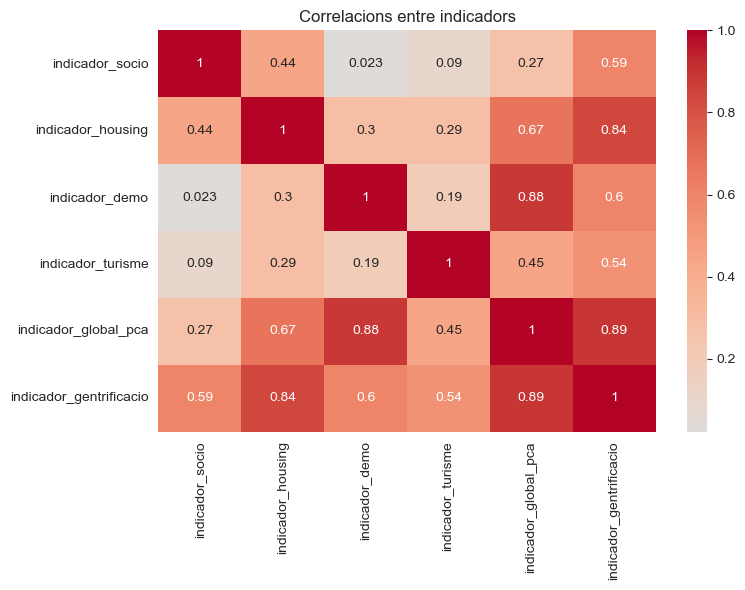

In [162]:
# ==================================================
# Correlacions entre indicadors
# ==================================================

plt.figure(figsize=(8, 6))

sns.heatmap(

    df_scaled[
        pca_vars
        + [
            "indicador_global_pca",
            "indicador_gentrificacio",
        ]
    ].corr(),

    annot=True,
    cmap="coolwarm",
    center=0,

)

plt.title(
    "Correlacions entre indicadors"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlacions_indicadors.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

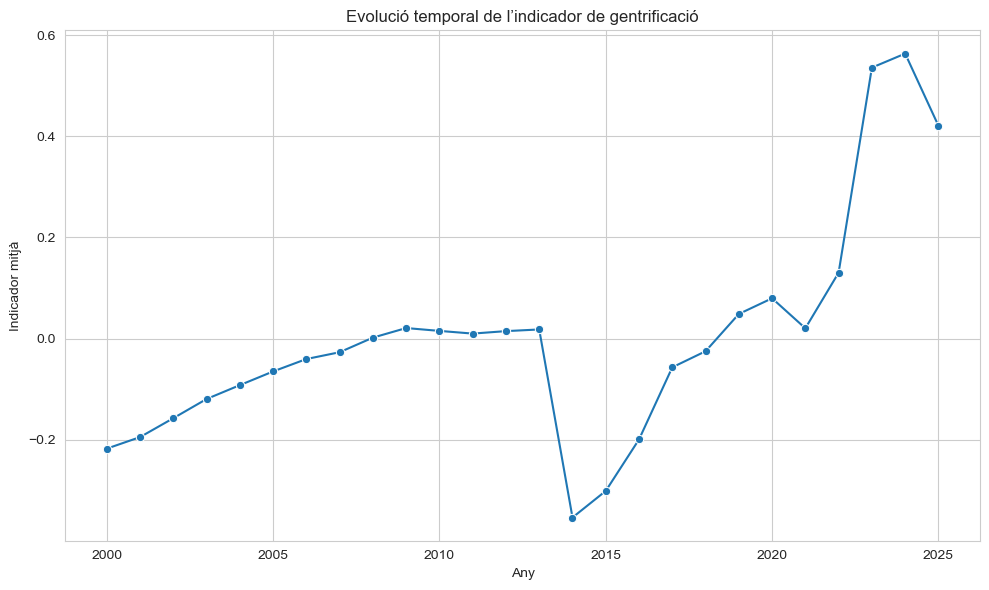

In [163]:
# ==================================================
# Evolució temporal de l'indicador
# ==================================================

df_mean = (

    df_scaled
    .groupby("any")[
        ["indicador_gentrificacio"]
    ]
    .mean()
    .reset_index()

)

plt.figure()

sns.lineplot(

    data=df_mean,
    x="any",
    y="indicador_gentrificacio",
    marker="o",

)

plt.title(
    "Evolució temporal de l’indicador de gentrificació"
)

plt.xlabel("Any")

plt.ylabel(
    "Indicador mitjà"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucio_indicador_gentrificacio.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

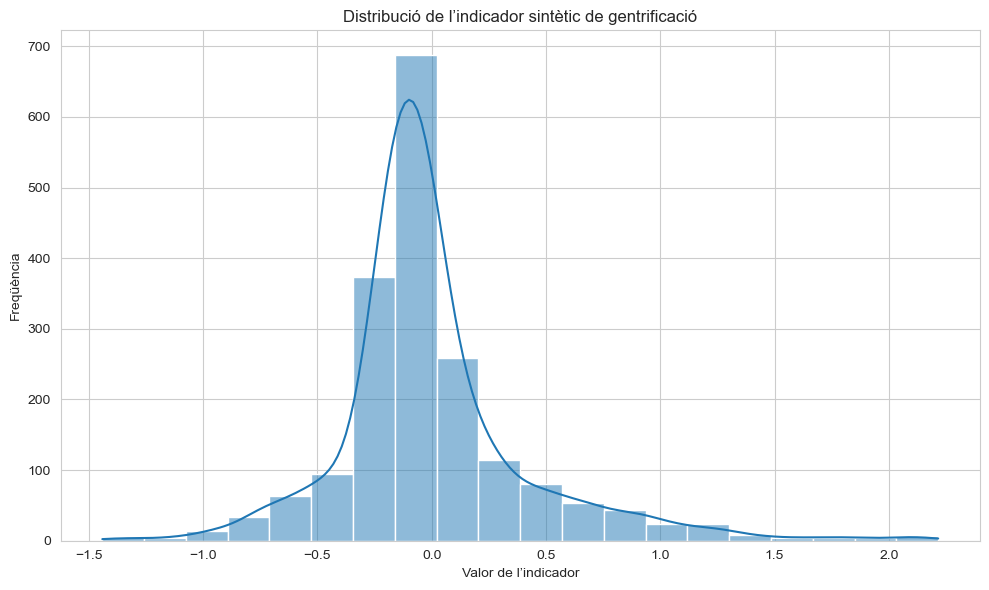

In [182]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_scaled['indicador_gentrificacio'],
    bins=20,
    kde=True
)

plt.title('Distribució de l’indicador sintètic de gentrificació')
plt.xlabel('Valor de l’indicador')
plt.ylabel('Freqüència')

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "distribucio_indicador_gentrificacio.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

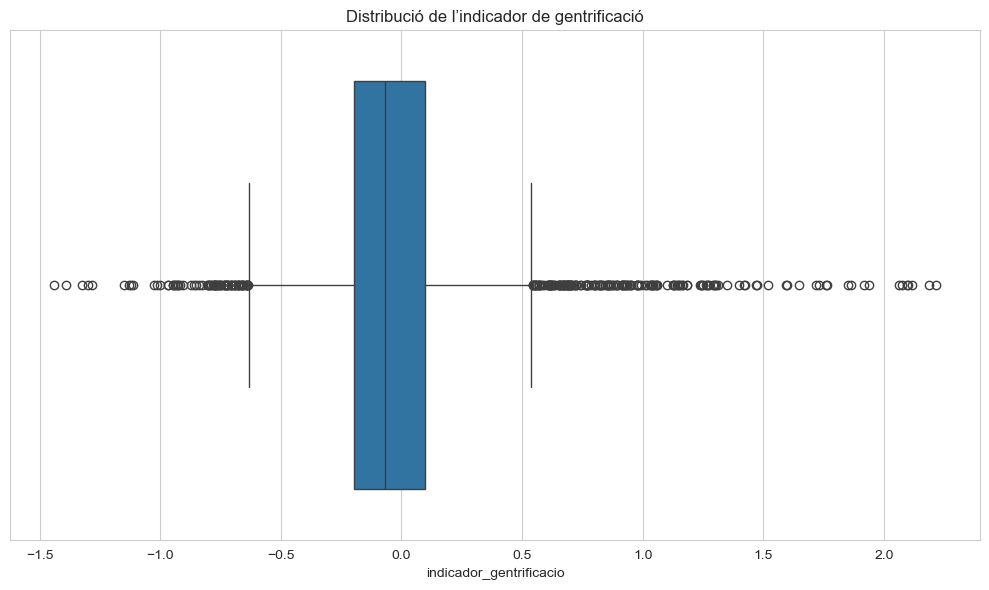

In [165]:
# ==================================================
# Distribució de l'indicador
# ==================================================

plt.figure()

sns.boxplot(
    x=df_scaled["indicador_gentrificacio"]
)

plt.title(
    "Distribució de l’indicador de gentrificació"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "boxplot_indicador_gentrificacio.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Visualitzant evolució temporal...


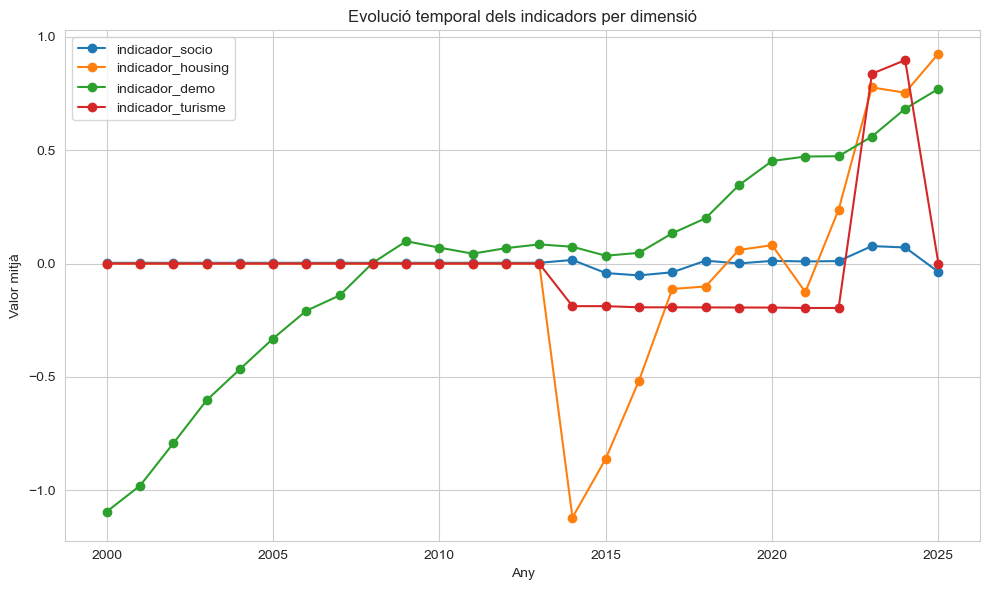

In [166]:
# ==================================================
# Evolució dels indicadors parcials
# ==================================================

print("Visualitzant evolució temporal...")

indicadors = [

    "indicador_socio",
    "indicador_housing",
    "indicador_demo",
    "indicador_turisme",

]

df_indicadors = (

    df_scaled
    .groupby("any")[indicadors]
    .mean()

)

plt.figure(figsize=(10, 6))

for col in indicadors:

    plt.plot(
        df_indicadors.index,
        df_indicadors[col],
        marker="o",
        label=col,
    )

plt.legend()

plt.xlabel("Any")

plt.ylabel("Valor mitjà")

plt.title(
    "Evolució temporal dels indicadors per dimensió"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "comparativa_dimensions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [168]:
# ==================================================
# Estadística descriptiva final
# ==================================================

variables = [

    "renda",
    "preu_lloguer",
    "poblacio_total",
    "atur",
    "Educació superior",
    "num_contractes",
    "superficie_mitja",
    "hut",
    "indicador_gentrificacio",

]

desc = (
    df_scaled[variables]
    .describe()
    .T
)

desc = desc[
    [
        "mean",
        "std",
        "min",
        "50%",
        "max",
    ]
]

desc.columns = [

    "Mitjana",
    "Desv. estàndard",
    "Mínim",
    "Mediana",
    "Màxim",

]

desc.index = [

    "Renda",
    "Preu lloguer",
    "Població total",
    "Atur",
    "Educació superior",
    "Contractes lloguer",
    "Superfície mitjana",
    "Habitatges turístics",
    "Indicador gentrificació",

]

desc = desc.round(2)

display(desc)

,Mitjana,Desv. estàndard,Mínim,Mediana,Màxim
Renda,0.00,1.00,-1.60,-0.13,3.41
Preu lloguer,0.00,1.00,-3.13,-0.01,3.30
Població total,22145.57,14459.20,439.00,21253.00,59221.00
Atur,3420.51,2777.55,10.00,2147.00,9980.00
Educació superior,5595.16,7369.79,0.00,2330.00,30992.00
Contractes lloguer,-0.00,1.00,-1.27,-0.30,2.74
Superfície mitjana,0.00,1.00,-2.57,-0.18,4.69
Habitatges turístics,0.00,1.00,-0.37,-0.32,8.01
Indicador gentrificació,0.00,0.42,-1.44,-0.07,2.22


In [170]:
# ==================================================
# Exportació taula LaTeX
# ==================================================

latex_table = desc.to_latex(

    caption=(
        "Estadístiques descriptives "
        "de les variables principals "
        "i de l’indicador de gentrificació."
    ),

    label="tab:estadistiques_indicadors",

    column_format="lccccc",

    escape=False,

)

with open(
    TABLES_DIR / "estadistiques_indicadors.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(latex_table)

print(
    "Taula LaTeX exportada."
)

Taula LaTeX exportada.


In [174]:
# ==================================================
# Exportació dataset final
# ==================================================

save_csv(
    df_scaled,
    DATA_PROCESSED / "indicators_dataset.csv"
)

print(
    "Dataset amb indicadors exportat correctament."
)

Dataset amb indicadors exportat correctament.
